# Stage 1 + 2 + 3 — End-to-end test on NEW images

**What this measures.** For every new image, the whole system's final answer — **prawn**, **tuna**, or **none**
(nothing found, or Track A judged it a false alarm) — compared with the folder the image came from. It also shows
*where* each miss was lost: Stage 1, Stage 2 or Track A.

**Before you run it**
1. **"New" means new.** Not used for training, tuning, checkpoint or model choice, or for looking at results.
   Cell 7 compares every test image with everything used in development, by picture content (mirrored copies
   included), and sets look-alikes aside.
2. **Folder labels must be right.** The `prawn` and `tuna` folders must hold frames that really show the disturbance, checked
   by eye. Raw survey footage is mostly clean water, so unchecked tuna frames would make ordinary water count as misses.
3. **Cetacean is not covered** (Track B has not been built).
4. **Run it once.** If you change anything after seeing these results, the images stop being a clean test.

**Needs:** `stage3_output/track_a_model.pkl`, saved by cell 13 of the Stage 3 notebook (`Stage_03_TrackA_v3_with_save.ipynb`).

In [1]:
# --- Cell 1: Imports and config ---
import csv
import json
import pickle
import random
import time
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation
from skimage.segmentation import slic
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy import ndimage
from scipy.stats import beta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Trained artefacts (same files the earlier stages used) ---
STAGE1_CONFIG_PATH = Path("stage1_final_config.json")
STAGE1_BUCKET_REF_PATH = Path("stage1_bucket_ref.pkl")
SEGFORMER_CHECKPOINT_PATH = Path("stage2_output/segformer_b0_epoch30.pt")
TRACK_A_BUNDLE_PATH = Path("stage3_output/track_a_model.pkl")

# --- NEW test images: one folder per TRUE class. UPDATE THESE. ---
TEST_DIRS = {
    "prawn": Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Test_data\PRAWNS"),        # frames that clearly show a prawn plume
    "tuna":  Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Test_data\TUNA"),         # frames that clearly show tuna boiling
    "clean": Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Test_data\SEA"),  # frames with nothing in them
}

# Optional: COCO annotation JSONs for the new prawn/tuna images. If given, cell 12 also measures mask accuracy (IoU).
TEST_ANNOTATIONS = {"prawn": None, "tuna": None}        # e.g. Path("new_prawn_instances.json")

# Annotation JSONs for images ALREADY used in Stage 2/3 development - used only to exactly exclude
# those specific filenames if a TEST_DIRS folder happens to be a superset that also contains them
# (e.g. UNSEEN_PRAWN_DIR contains the 25 annotated images alongside the 57 genuinely unseen ones).
# Leave a path as None if you are not reusing that raw pool.
ANNOTATION_JSONS = {
    "prawn": Path("prawn_instances_default_t1.json"),
    "tuna": Path("tuna_instances_default_t1.json"),
}

# --- Everything used during development. Cell 7 checks the test images against these. ---
# The two raw pools are included on purpose: Stage 1 was tuned on them and ~200-image samples were used to test.
# Remove a line only if you deliberately want to draw test images from that pool.
DEV_IMAGE_DIRS = [
    Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_02\prawn_annotation_training\images\default"),
    Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_02\tuna_annotation_training\images\default"),
    Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_01\data\normal_sea\heldout_split"),
    Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_01\data\normal_sea\baseline_split"),
    Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Val_data\TUNA"),   # used to retrain Track A
    Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Val_data\SEA"),    # used to retrain Track A
]
# NOTE: the raw UNSEEN_PRAWN_DIR / UNSEEN_TUNA_DIR pools (Stage_01/data/prawns, .../tuna) are NOT listed
# here on purpose. If you are reusing one of those pools as a TEST_DIRS source (e.g. the 57-image prawn
# pool from the Stage 1+2 connected-pipeline test), listing it here would make every test image match
# itself at similarity 1.000. The 25/26 annotated filenames inside those pools are excluded exactly,
# by filename, in cell 7 instead - see ANNOTATION_JSONS below.
RUN_NEAR_DUPLICATE_AUDIT = True
# Featureless open water naturally scores high similarity against OTHER unrelated open water at
# low resolution, so clean water needs a much higher bar than prawn/tuna, which have distinctive
# content. A per-class threshold - default 0.95, clean overridden to 0.985.
NEAR_DUPLICATE_THRESHOLD = {"prawn": 0.95, "tuna": 0.95, "clean": 0.985}
EXCLUDE_SUSPECTED_DUPLICATES = True

# --- Settings that must match what Track A was trained with (checked below against the saved model) ---
STAGE2_PROB_THRESHOLD = 0.35
STAGE2_MIN_MASK_PIXELS = 80
STAGE1_DILATION_ITERS = 2
CROP_PADDING_PX = 20
RING_PX = 25
MIN_NATIVE_PX = 24
MIN_NATIVE_MASK_PX = 30

PRAWN_IOU_CEILING = 0.5867      # human-agreement ceilings measured during annotation
TUNA_IOU_CEILING = 0.7204
OUTPUT_DIR = Path("stage123_test_output")
OUTPUT_DIR.mkdir(exist_ok=True)

with open(STAGE1_CONFIG_PATH) as f:
    stage1_config = json.load(f)
with open(STAGE1_BUCKET_REF_PATH, "rb") as f:
    stage1_bucket_ref = pickle.load(f)
with open(TRACK_A_BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

# ---- refuse to run if anything differs from what Track A was trained with ----
mine = {"prob": STAGE2_PROB_THRESHOLD, "min_px": STAGE2_MIN_MASK_PIXELS, "dilation": STAGE1_DILATION_ITERS,
        "crop_pad": CROP_PADDING_PX, "ring_px": RING_PX, "min_native_px": MIN_NATIVE_PX,
        "min_native_mask_px": MIN_NATIVE_MASK_PX}
mismatch = {k: (bundle["settings"].get(k), v) for k, v in mine.items() if bundle["settings"].get(k) != v}
if bundle["stage1_config"] != stage1_config:
    mismatch["stage1_config"] = "the Stage 1 config file differs from the one Track A was trained with"
if str(bundle["segformer_checkpoint"]).replace("\\", "/") != str(SEGFORMER_CHECKPOINT_PATH).replace("\\", "/"):
    mismatch["segformer_checkpoint"] = (bundle["segformer_checkpoint"], str(SEGFORMER_CHECKPOINT_PATH))
if mismatch:
    raise RuntimeError(f"Settings differ from what Track A was trained with, so results would not be valid: {mismatch}")

IMG_SIZE = tuple(stage1_config["img_size"])
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRACK_A_MODEL = bundle["model"]
TRACK_A_COLS = bundle["columns"]
TRACK_A_CLASSES = list(bundle["classes"])
print(f"Settings match. Track A: feature set '{bundle['feature_set']}', trained on {bundle['n_train_rows']} rows "
      f"{bundle['train_class_counts']}.  Device: {device}")
random.seed(42)
np.random.seed(42)

Settings match. Track A: feature set 'everything_native', trained on 188 rows {'prawn': 15, 'tuna': 119, 'other': 54}.  Device: cpu


In [2]:
# --- Cell 2: Load SegFormer-B0 with the best checkpoint ---

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512", num_labels=2,
    id2label={0: "background", 1: "anomaly"}, label2id={"background": 0, "anomaly": 1},
    ignore_mismatched_sizes=True,
)
model.load_state_dict(torch.load(SEGFORMER_CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()
print(f"Loaded checkpoint: {SEGFORMER_CHECKPOINT_PATH}")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Loaded checkpoint: stage2_output\segformer_b0_epoch30.pt


In [3]:
# --- Cell 3: Ported Stage 1 detector (texture rule OR local-brightness rule) ---

S1_N_SEGMENTS = stage1_config["n_segments"]
S1_COMPACTNESS = stage1_config["compactness"]
S1_GLCM_LEVELS = stage1_config["glcm_levels"]
S1_Z_THRESH = stage1_config["z_thresh"]
S1_GLINT_THRESH = stage1_config["glint_thresh"]
S1_MIN_COMPONENT_AREA_PX = stage1_config["min_component_area_px"]
S1_MIN_FEATURES_FLAGGED = stage1_config["min_features_flagged"]
S1_BUCKET_EDGES = np.array(stage1_config["bucket_edges"])
S1_LOCAL_Z_THRESH = stage1_config.get("local_z_thresh", 999)
S1_MIN_AREA_LOCAL = stage1_config.get("min_area_local", 999999999)
FEATURE_KEYS = ["contrast_L", "homogeneity_L", "energy_L", "contrast_a", "lbp_var"]

def suppress_glint(img_bgr, thresh=S1_GLINT_THRESH, dilate_iter=2):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0]
    glint_mask = (L > thresh).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    glint_mask = cv2.dilate(glint_mask, kernel, iterations=dilate_iter)
    return cv2.morphologyEx(glint_mask, cv2.MORPH_CLOSE, kernel)

def preprocess_image_s1(path, glint_thresh=S1_GLINT_THRESH):
    img_bgr = cv2.resize(cv2.imread(str(path)), IMG_SIZE)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    glint_mask = suppress_glint(img_bgr, glint_thresh)
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return lab, glint_mask, rgb

def quantize_s1(patch, levels=S1_GLCM_LEVELS):
    return (patch.astype(np.float32) / 256 * levels).astype(np.uint8)

def glcm_props_s1(patch_q, levels=S1_GLCM_LEVELS):
    glcm = graycomatrix(patch_q, distances=[1], angles=[0], levels=levels, symmetric=True, normed=True)
    return (float(graycoprops(glcm, 'contrast')[0, 0]), float(graycoprops(glcm, 'homogeneity')[0, 0]), float(graycoprops(glcm, 'energy')[0, 0]))

def extract_superpixel_features_s1(img_lab, glint_mask, n_segments=S1_N_SEGMENTS, compactness=S1_COMPACTNESS):
    L_channel, a_channel = img_lab[:, :, 0], img_lab[:, :, 1]
    segments = slic(img_lab, n_segments=n_segments, compactness=compactness, start_label=1)
    objects = ndimage.find_objects(segments)
    features = []
    for seg_id, bbox in enumerate(objects, start=1):
        if bbox is None:
            continue
        y_slice, x_slice = bbox
        local_mask = segments[y_slice, x_slice] == seg_id
        if glint_mask[y_slice, x_slice][local_mask].mean() > 0.5:
            continue
        patch_L, patch_a = L_channel[y_slice, x_slice], a_channel[y_slice, x_slice]
        if patch_L.shape[0] < 2 or patch_L.shape[1] < 2:
            continue
        contrast_L, homogeneity_L, energy_L = glcm_props_s1(quantize_s1(patch_L))
        contrast_a, _, _ = glcm_props_s1(quantize_s1(patch_a))
        lbp_var = float(np.var(local_binary_pattern(patch_L, P=8, R=1, method='uniform')))
        features.append({"seg_id": int(seg_id), "contrast_L": contrast_L, "homogeneity_L": homogeneity_L,
                          "energy_L": energy_L, "contrast_a": contrast_a, "lbp_var": lbp_var, "mean_L": float(patch_L.mean())})
    return segments, features

def image_sea_state_score(img_lab, glint_mask):
    L = img_lab[:, :, 0]
    valid = glint_mask == 0
    return float(np.mean(L[valid] if valid.any() else L))

def assign_bucket_from_score(score, edges=S1_BUCKET_EDGES):
    return int(np.searchsorted(edges, score))

def score_region_deviation_s1(feat, baseline_ref, z_thresh, min_features_flagged):
    z_scores = {k: abs(feat[k] - baseline_ref[k][0]) / (baseline_ref[k][1] + 1e-6) for k in FEATURE_KEYS}
    return sum(1 for z in z_scores.values() if z > z_thresh) >= min_features_flagged

def _region_with_bbox(flagged_mask, min_area, dilation_iters=STAGE1_DILATION_ITERS):
    if dilation_iters > 0:
        flagged_mask = ndimage.binary_dilation(flagged_mask, iterations=dilation_iters)
    labeled, n_components = ndimage.label(flagged_mask)
    if n_components == 0:
        return False, 0, None
    sizes = ndimage.sum(flagged_mask, labeled, range(1, n_components + 1))
    biggest_label = int(np.argmax(sizes)) + 1
    max_component = float(sizes[biggest_label - 1])
    is_detected = max_component >= min_area
    bbox = None
    if is_detected:
        y_slice, x_slice = ndimage.find_objects(labeled)[biggest_label - 1]
        bbox = (x_slice.start, y_slice.start, x_slice.stop, y_slice.stop)
    return is_detected, max_component, bbox

def texture_rule_with_bbox(segments, feats, baseline_ref, z_thresh=S1_Z_THRESH, min_area=S1_MIN_COMPONENT_AREA_PX, min_features_flagged=S1_MIN_FEATURES_FLAGGED):
    flagged_ids = {f["seg_id"] for f in feats if score_region_deviation_s1(f, baseline_ref, z_thresh, min_features_flagged)}
    if not flagged_ids:
        return False, 0, None
    return _region_with_bbox(np.isin(segments, list(flagged_ids)), min_area)

def local_brightness_rule_with_bbox(feats, segments, local_z_thresh=S1_LOCAL_Z_THRESH, min_area_local=S1_MIN_AREA_LOCAL):
    if not feats:
        return False, 0, None
    mean_Ls = np.array([f["mean_L"] for f in feats])
    img_mean, img_std = mean_Ls.mean(), mean_Ls.std()
    flagged_ids = {f["seg_id"] for f in feats if abs(f["mean_L"] - img_mean) / (img_std + 1e-6) > local_z_thresh}
    if not flagged_ids:
        return False, 0, None
    return _region_with_bbox(np.isin(segments, list(flagged_ids)), min_area_local)

def get_flagging_result_with_bbox(segments, feats, baseline_ref):
    tex_detected, tex_area, tex_bbox = texture_rule_with_bbox(segments, feats, baseline_ref)
    local_detected, local_area, local_bbox = local_brightness_rule_with_bbox(feats, segments)
    if not tex_detected and not local_detected:
        return False, 0, None
    if tex_detected and local_detected:
        return (True, tex_area, tex_bbox) if tex_area >= local_area else (True, local_area, local_bbox)
    return (True, tex_area, tex_bbox) if tex_detected else (True, local_area, local_bbox)

print("Stage 1 detector ported and ready.")

Stage 1 detector ported and ready.


In [4]:
# --- Cell 4: Connected pipeline (Stage 1 -> crop -> Stage 2) ---

def run_connected_pipeline(path, bucket_ref=stage1_bucket_ref):
    lab, glint_mask, rgb = preprocess_image_s1(path)
    segments, feats = extract_superpixel_features_s1(lab, glint_mask)
    bucket = assign_bucket_from_score(image_sea_state_score(lab, glint_mask))
    is_detected, max_component, bbox = get_flagging_result_with_bbox(segments, feats, bucket_ref[bucket])

    result = {"path": str(path), "rgb": rgb, "is_detected": is_detected,
              "bbox": None, "crop": None, "stage2_mask": None, "n_flagged_px_stage2": 0,
              "stage2_raw_px": 0, "stage2_max_prob": None}

    if is_detected and bbox is not None:
        x0, y0, x1, y1 = bbox
        H, W = rgb.shape[:2]
        x0p, y0p = max(0, x0 - CROP_PADDING_PX), max(0, y0 - CROP_PADDING_PX)
        x1p, y1p = min(W, x1 + CROP_PADDING_PX), min(H, y1 + CROP_PADDING_PX)
        crop = rgb[y0p:y1p, x0p:x1p]
        result["bbox"] = (x0p, y0p, x1p, y1p)

        if crop.size > 0:
            crop_img = Image.fromarray(crop).resize(IMG_SIZE, Image.BILINEAR)
            crop_arr = np.array(crop_img, dtype=np.float32) / 255.0
            crop_norm = (crop_arr - IMAGENET_MEAN) / IMAGENET_STD
            pixel_values = torch.from_numpy(crop_norm.transpose(2, 0, 1)).unsqueeze(0).to(device)
            with torch.no_grad():
                outputs = model(pixel_values=pixel_values)
                logits = F.interpolate(outputs.logits, size=IMG_SIZE, mode="bilinear", align_corners=False)
                probs = F.softmax(logits, dim=1)[0, 1].cpu().numpy()
            pred = (probs > STAGE2_PROB_THRESHOLD).astype(np.uint8)
            result["stage2_raw_px"] = int(pred.sum())            # pixels above threshold, before the noise floor
            result["stage2_max_prob"] = float(probs.max())       # highest anomaly probability anywhere in the crop
            if pred.sum() < STAGE2_MIN_MASK_PIXELS:
                pred = np.zeros_like(pred)
            result["crop"] = crop_arr
            result["stage2_mask"] = pred
            result["n_flagged_px_stage2"] = int(pred.sum())

    return result

print("Connected pipeline ready.")

Connected pipeline ready.


In [5]:
# --- Cell 6: Track A features: shape, signature (as-is and native-scale), scene, scale diagnostics ---

LABELS = ["prawn", "tuna", "other"]

def _sobel_mag(gray):
    return np.sqrt(cv2.Sobel(gray, cv2.CV_32F, 1, 0) ** 2 + cv2.Sobel(gray, cv2.CV_32F, 0, 1) ** 2)

def texture_at_native_scale(crop_u8, mask, bbox, src_size):
    """Texture measured on the crop shrunk back to the ORIGINAL file's pixel grid, so it is not
    inflated or deflated by our own resizing. The box covers (box_w x src_w / 512) file pixels across;
    the 512x512 crop is shrunk to that size (never enlarged, never below MIN_NATIVE_PX)."""
    x0, y0, x1, y1 = bbox
    src_w, src_h = src_size
    fw, fh = IMG_SIZE
    nw = int(np.clip(round((x1 - x0) * src_w / fw), MIN_NATIVE_PX, fw))
    nh = int(np.clip(round((y1 - y0) * src_h / fh), MIN_NATIVE_PX, fh))
    small = cv2.resize(crop_u8, (nw, nh), interpolation=cv2.INTER_AREA)
    m_small = cv2.resize(mask.astype(np.float32), (nw, nh), interpolation=cv2.INTER_AREA) > 0.5
    if m_small.sum() < MIN_NATIVE_MASK_PX:
        return None
    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY).astype(np.float32)
    L = cv2.cvtColor(small, cv2.COLOR_RGB2LAB)[:, :, 0].astype(np.float32)
    return float(L[m_small].std()), float(_sobel_mag(gray)[m_small].mean()), nw

def extract_track_a_features(result):
    """Returns (features, None) on success, or (None, reason) if the row is unusable.
    Needs 'stage2_mask' (512x512 0/1), 'crop' (512x512x3 float 0-1 RGB), 'bbox' and 'path'."""
    mask, crop, bbox = result.get("stage2_mask"), result.get("crop"), result.get("bbox")
    if mask is None or crop is None or bbox is None:
        return None, "missing crop/mask/box"
    mask_area = int(mask.sum())
    if mask_area == 0:
        return None, "empty mask"
    inside = mask.astype(bool)

    # ---- shape (baseline only) ----
    ys, xs = np.where(inside)
    mask_h = ys.max() - ys.min() + 1
    mask_w = xs.max() - xs.min() + 1
    elongation = max(mask_w, mask_h) / max(1, min(mask_w, mask_h))
    extent = mask_area / (mask_w * mask_h)
    fill_ratio = mask_area / mask.size                       # fraction of the crop covered by the mask

    # ---- pixel content on the stretched 512x512 crop ----
    crop_u8 = (np.clip(crop, 0, 1) * 255).astype(np.uint8)   # RGB
    lab = cv2.cvtColor(crop_u8, cv2.COLOR_RGB2LAB).astype(np.float32)
    gray = cv2.cvtColor(crop_u8, cv2.COLOR_RGB2GRAY).astype(np.float32)
    grad = _sobel_mag(gray)
    L, a, b = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * RING_PX + 1, 2 * RING_PX + 1))
    ring = cv2.dilate(mask.astype(np.uint8), kernel).astype(bool) & ~inside
    if ring.sum() < 50:
        ring = ~inside
    if ring.sum() < 50:
        return None, "mask covers almost the whole crop"

    # ---- native-scale texture + scale diagnostics ----
    with Image.open(result["path"]) as im:
        src_size = im.size                                    # (width, height) of the original file
    native = texture_at_native_scale(crop_u8, mask, bbox, src_size)
    if native is None:
        return None, "mask too small at native scale"
    in_L_std_native, in_edge_native, native_w = native

    box_w = max(1, bbox[2] - bbox[0])
    return {
        # shape
        "fill_ratio": fill_ratio, "elongation": elongation, "extent": extent,
        # signature, measured on the stretched crop (kept as a diagnostic)
        "in_L_std": float(L[inside].std()), "in_edge": float(grad[inside].mean()),
        # signature, measured at native scale
        "in_L_std_native": in_L_std_native, "in_edge_native": in_edge_native,
        "contrast_ring": float(L[inside].mean() - L[ring].mean()),
        # scene
        "in_L": float(L[inside].mean()), "ring_L": float(L[ring].mean()),
        "in_a": float(a[inside].mean()), "ring_a": float(a[ring].mean()),
        "in_b": float(b[inside].mean()), "ring_b": float(b[ring].mean()),
        # scale diagnostics
        "crop_scale": IMG_SIZE[0] / box_w,                                   # stretch of Stage 1's box to 512
        "total_upscale": IMG_SIZE[0] * IMG_SIZE[0] / (box_w * src_size[0]),  # stretch relative to the real photo
        "src_w": float(src_size[0]), "native_w": float(native_w),
    }, None

print("Feature function ready.")

Feature function ready.


In [6]:
# --- Cell 6: The full system for one image: Stage 1 -> crop -> Stage 2 -> Track A ---
# Final answer is 'prawn', 'tuna' or 'none'. 'none' means: not flagged, no Stage 2 mask, mask could not be
# measured, or Track A called it 'other' (a false alarm). ended_at says which stage made the decision.

def run_all_stages(path):
    res = run_connected_pipeline(path)
    rec = {"path": str(path), "stage1_flagged": bool(res["is_detected"]), "stage2_mask_px": int(res["n_flagged_px_stage2"]),
           "stage2_max_prob": res["stage2_max_prob"], "track_a_label": None, "track_a_probs": None,
           "final": "none", "ended_at": "", "reason": ""}
    if not res["is_detected"]:
        rec.update(ended_at="stage1", reason="Stage 1 did not flag the image")
        return rec, res
    if res["crop"] is None:
        rec.update(ended_at="stage2", reason="empty crop")
        return rec, res
    if res["n_flagged_px_stage2"] == 0:
        if res["stage2_raw_px"] == 0:
            why = f"Stage 2 found nothing (max prob {res['stage2_max_prob']:.2f})"
        else:
            why = f"Stage 2 mask under the {STAGE2_MIN_MASK_PIXELS}px floor ({res['stage2_raw_px']} px)"
        rec.update(ended_at="stage2", reason=why)
        return rec, res
    feats, why = extract_track_a_features(res)
    if feats is None:
        rec.update(ended_at="track_a", reason=f"Track A could not measure the mask: {why}")
        return rec, res
    x = np.array([[feats[c] for c in TRACK_A_COLS]], dtype=float)
    probs = TRACK_A_MODEL.predict_proba(x)[0]
    label = TRACK_A_CLASSES[int(np.argmax(probs))]
    rec.update(track_a_label=label, track_a_probs={c: float(p) for c, p in zip(TRACK_A_CLASSES, probs)},
               ended_at="track_a", final=label if label in ("prawn", "tuna") else "none",
               reason=f"Track A said {label} ({probs.max():.2f})")
    return rec, res

print("Full pipeline ready.")

Full pipeline ready.


In [7]:
# --- Cell 7: Are the "new" images really new? ---
# Each test image is compared, by picture content, with every image used in development. Mirrored and
# flipped copies are caught too. This is a screening tool, not proof: look at anything it flags.

IMG_EXTS = {".jpg", ".jpeg", ".png"}

def list_images(folder):
    return sorted(p for p in Path(folder).glob("*") if p.suffix.lower() in IMG_EXTS)

def _norm(a):
    a = a - a.mean()
    n = np.linalg.norm(a)
    return (a / n).ravel() if n > 1e-6 else np.zeros(a.size, np.float32)

def load_gray32(path):
    with Image.open(path) as im:
        im.draft("L", (128, 128))
        return np.asarray(im.convert("L").resize((32, 32), Image.BILINEAR), dtype=np.float32)

known_annotated = {}   # class -> set of filenames already used in Stage 2/3 development
for cls, jp in ANNOTATION_JSONS.items():
    if jp is not None and Path(jp).exists():
        known_annotated[cls] = {im["file_name"] for im in json.load(open(jp))["images"]}

test_items = []      # (true class, path)
for cls, folder in TEST_DIRS.items():
    paths = list_images(folder)
    already = known_annotated.get(cls, set())
    before = len(paths)
    paths = [p for p in paths if p.name not in already]
    n_excluded = before - len(paths)
    tag = f" (excluded {n_excluded} already used in training/eval, by exact filename)" if n_excluded else ""
    print(f"{cls:<6} {len(paths):>4} test images in {folder}{tag}")
    test_items += [(cls, p) for p in paths]
assert test_items, "No test images found - check TEST_DIRS in cell 1."

audit_rows, suspects = [], {}
if RUN_NEAR_DUPLICATE_AUDIT:
    dev_paths = []
    for d in DEV_IMAGE_DIRS:
        if not Path(d).exists():
            print(f"  WARNING: development folder not found, skipped: {d}")
            continue
        dev_paths += list_images(d)
    print(f"Fingerprinting {len(dev_paths)} development images (a minute or two)...")
    dev_vecs, dev_ok = [], []
    for p in dev_paths:
        try:
            dev_vecs.append(_norm(load_gray32(p)))
            dev_ok.append(p)
        except Exception:
            pass
    dev_names = {p.name for p in dev_ok}
    if not dev_vecs:
        print("WARNING: no development images could be read - the audit was skipped.")
    else:
        D = np.stack(dev_vecs)                                        # (n_dev, 1024)
        for cls, p in test_items:
            g = load_gray32(p)
            variants = np.stack([_norm(g), _norm(g[:, ::-1]), _norm(g[::-1, :]), _norm(g[::-1, ::-1])])
            sims = (variants @ D.T).max(axis=0)                       # best of the four orientations
            j = int(sims.argmax())
            row = {"path": str(p), "true": cls, "best_similarity": float(sims[j]), "closest_dev_image": str(dev_ok[j]),
                   "same_filename_as_dev": p.name in dev_names}
            thr = NEAR_DUPLICATE_THRESHOLD.get(cls, 0.95) if isinstance(NEAR_DUPLICATE_THRESHOLD, dict) else NEAR_DUPLICATE_THRESHOLD
            row["threshold_used"] = thr
            row["flagged"] = row["best_similarity"] >= thr or row["same_filename_as_dev"]
            audit_rows.append(row)
            if row["flagged"]:
                suspects[str(p)] = row

        print(f"\nSet aside as look-alikes of development images: {len(suspects)} of {len(test_items)}")
        for r in sorted(suspects.values(), key=lambda r: -r["best_similarity"])[:30]:
            tag = " (same filename)" if r["same_filename_as_dev"] else ""
            print(f"  {r['best_similarity']:.3f}  {Path(r['path']).name[:34]:<34} ~ {Path(r['closest_dev_image']).name[:34]}{tag}")
        others = sorted((r for r in audit_rows if not r["flagged"]), key=lambda r: -r["best_similarity"])[:5]
        if others:
            print("\nClosest matches among the images kept (for calibration - anything near the threshold deserves a look):")
            for r in others:
                print(f"  {r['best_similarity']:.3f}  {Path(r['path']).name[:34]:<34} ~ {Path(r['closest_dev_image']).name[:34]}")

excluded = set(suspects) if EXCLUDE_SUSPECTED_DUPLICATES else set()
scored_items = [(c, p) for c, p in test_items if str(p) not in excluded]
print("\nImages that will be scored:  " + ",  ".join(
    f"{c}: {sum(1 for cc, _ in scored_items if cc == c)} of {sum(1 for cc, _ in test_items if cc == c)}" for c in TEST_DIRS))

prawn    57 test images in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Test_data\PRAWNS (excluded 25 already used in training/eval, by exact filename)
tuna    236 test images in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Test_data\TUNA
clean   457 test images in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Test_data\SEA
Fingerprinting 6142 development images (a minute or two)...

Set aside as look-alikes of development images: 555 of 750
  1.000  DSC_1478_FB_840_224x224_HM_GN_331x ~ DSC_1478_FB_840_224x224_HM_GN_331x (same filename)
  1.000  DSC_2347_FA_6630_224x224_HF_MB_331 ~ DSC_2347_FA_6630_224x224_HF_MB_331 (same filename)
  1.000  DSC_2940_FA_13170_224x224_HF_GN_33 ~ DSC_2940_FA_13170_224x224_HF_GN_33 (same filename)
  1.000  DSC_3170_FB_14860_224x224_MB_331x3 ~ DSC_3170_FB_14860_224x224_MB_331x3 (same filename)
  1.000  DSC_2347_FB_6060_224x224_HF_331x33 ~ DSC_2347_FB_6060_224x224_

In [8]:
# --- Cell 8: Run the full system on every scored test image ---

records, kept, run_errors = [], {}, []
t0 = time.time()
for i, (cls, p) in enumerate(scored_items, start=1):
    try:
        rec, res = run_all_stages(p)
    except Exception as e:
        run_errors.append((str(p), repr(e)))
        continue
    rec["true"] = cls
    rec["expected"] = cls if cls in ("prawn", "tuna") else "none"
    rec["correct"] = rec["final"] == rec["expected"]
    records.append(rec)
    kept[rec["path"]] = {"bbox": res["bbox"], "stage2_mask": res["stage2_mask"]}
    if not rec["correct"]:                               # keep the pictures only where the gallery will need them
        kept[rec["path"]].update(rgb=res["rgb"], crop=res["crop"])
    if i % 10 == 0 or i == len(scored_items):
        el = time.time() - t0
        print(f"  ...{i}/{len(scored_items)} done ({el:.0f}s, about {el / i * (len(scored_items) - i):.0f}s left)")

print(f"\nScored {len(records)} images.")
if run_errors:
    print(f"WARNING: {len(run_errors)} image(s) crashed the pipeline and are NOT in the results:")
    for path, err in run_errors[:10]:
        print(f"  {Path(path).name}: {err}")

  ...10/195 done (15s, about 285s left)
  ...20/195 done (31s, about 272s left)
  ...30/195 done (47s, about 256s left)
  ...40/195 done (62s, about 239s left)
  ...50/195 done (76s, about 221s left)
  ...60/195 done (91s, about 205s left)
  ...70/195 done (107s, about 190s left)
  ...80/195 done (121s, about 174s left)
  ...90/195 done (135s, about 157s left)
  ...100/195 done (149s, about 142s left)
  ...110/195 done (164s, about 127s left)
  ...120/195 done (179s, about 112s left)
  ...130/195 done (193s, about 97s left)
  ...140/195 done (208s, about 82s left)
  ...150/195 done (224s, about 67s left)
  ...160/195 done (239s, about 52s left)
  ...170/195 done (253s, about 37s left)
  ...180/195 done (268s, about 22s left)
  ...190/195 done (279s, about 7s left)
  ...195/195 done (283s, about 0s left)

Scored 195 images.


In [9]:
# --- Cell 9: Accuracy of the whole system ---

def ci(k, n, a=0.05):
    if n == 0:
        return float("nan"), float("nan")
    lo = 0.0 if k == 0 else beta.ppf(a / 2, k, n - k + 1)
    hi = 1.0 if k == n else beta.ppf(1 - a / 2, k + 1, n - k)
    return lo, hi

def rate(k, n):
    if n == 0:
        return "n/a (no images)"
    lo, hi = ci(k, n)
    return f"{k}/{n} = {100 * k / n:5.1f}%   (95% CI {100 * lo:.0f}-{100 * hi:.0f}%)"

TRUE = ["prawn", "tuna", "clean"]
PRED = ["prawn", "tuna", "none"]
cm = np.zeros((3, 3), dtype=int)
for r in records:
    cm[TRUE.index(r["true"]), PRED.index(r["final"])] += 1
by_class = lambda c: [r for r in records if r["true"] == c]

print("Final answer vs the folder each image came from (rows = truth, columns = system's answer)")
print(f"{'':>8}" + "".join(f"{p:>8}" for p in PRED))
for i, t in enumerate(TRUE):
    print(f"{t:>8}" + "".join(f"{cm[i, j]:>8}" for j in range(3)))

print("\nHOW OFTEN THE SYSTEM WAS RIGHT")
for c in ["prawn", "tuna"]:
    rs = by_class(c)
    n = len(rs)
    print(f"{c} images   right answer:              {rate(sum(r['correct'] for r in rs), n)}")
    print(f"{'':<{len(c) + 8}}found at all (any species): {rate(sum(r['final'] != 'none' for r in rs), n)}")
    print(f"{'':<{len(c) + 8}}wrong species:              {sum(r['final'] not in ('none', c) for r in rs)}")
rs = by_class("clean")
print(f"clean water   correctly ignored:         {rate(sum(r['correct'] for r in rs), len(rs))}")
print(f"{'':<13}false alarms in the final answer: {rate(sum(r['final'] != 'none' for r in rs), len(rs))}")
print("\nWHEN THE SYSTEM SAID 'prawn' or 'tuna', HOW OFTEN WAS IT RIGHT?")
for j, c in enumerate(["prawn", "tuna"]):
    print(f"  '{c}' answers: {rate(int(cm[j, j]), int(cm[:, j].sum()))}")
print(f"\nOVERALL: {rate(int(np.trace(cm)), int(cm.sum()))}")

print("\nWHERE EACH GROUP GOES, STAGE BY STAGE  (how many images are still alive after each stage)")
print(f"{'group':<8}{'images':>7}{'Stage 1 flagged':>18}{'Stage 2 mask':>15}{'Track A measured':>18}{'final: prawn/tuna':>19}")
funnel = {}
for c in TRUE:
    rs = by_class(c)
    n = len(rs)
    row = [n, sum(r["stage1_flagged"] for r in rs), sum(r["stage2_mask_px"] > 0 for r in rs),
           sum(r["track_a_label"] is not None for r in rs), sum(r["final"] != "none" for r in rs)]
    funnel[c] = row
    pct = lambda k: f"{k} ({100 * k / n:.0f}%)" if n else "-"
    print(f"{c:<8}{n:>7}{pct(row[1]):>18}{pct(row[2]):>15}{pct(row[3]):>18}{pct(row[4]):>19}")
print("(for clean water, LOWER is better: those are false alarms surviving each stage)")

def miss_cause(r, true_class):
    if r["final"] not in ("none", true_class):
        return f"called it {r['final']}"
    if r["ended_at"] == "stage1":
        return "Stage 1 did not flag it"
    if r["ended_at"] == "stage2":
        return "Stage 2 found no usable mask"
    if r["track_a_label"] is None:
        return "Track A could not measure the mask"
    return "Track A called it 'other'"

print("\nWHERE THE MISSES WERE LOST")
for c in ["prawn", "tuna"]:
    misses = [r for r in by_class(c) if not r["correct"]]
    print(f"{c}: {len(misses)} missed  ->  {dict(Counter(miss_cause(r, c) for r in misses)) or 'none'}")
fa = [r for r in by_class("clean") if not r["correct"]]
print(f"clean: {len(fa)} false alarms  ->  {dict(Counter('called it ' + r['final'] for r in fa)) or 'none'}")

n_min = min([len(by_class(c)) for c in TRUE if by_class(c)] or [0])
if n_min:
    print(f"\nHow much to trust these numbers: with {n_min} images in the smallest group, even a perfect score only proves "
          f"about {100 * ci(n_min, n_min)[0]:.0f}% or better (95% confidence).")

summary = {"confusion_matrix": {"rows_true": TRUE, "cols_predicted": PRED, "values": cm.tolist()},
           "funnel": {c: dict(zip(["images", "stage1_flagged", "stage2_mask", "track_a_measured", "final_prawn_or_tuna"], v))
                      for c, v in funnel.items()},
           "overall_correct": int(np.trace(cm)), "overall_n": int(cm.sum()),
           "set_aside_as_lookalikes": len(suspects), "crashed": len(run_errors)}

Final answer vs the folder each image came from (rows = truth, columns = system's answer)
           prawn    tuna    none
   prawn      23       2       7
    tuna       0      85      58
   clean       0       0      20

HOW OFTEN THE SYSTEM WAS RIGHT
prawn images   right answer:              23/32 =  71.9%   (95% CI 53-86%)
             found at all (any species): 25/32 =  78.1%   (95% CI 60-91%)
             wrong species:              2
tuna images   right answer:              85/143 =  59.4%   (95% CI 51-68%)
            found at all (any species): 85/143 =  59.4%   (95% CI 51-68%)
            wrong species:              0
clean water   correctly ignored:         20/20 = 100.0%   (95% CI 83-100%)
             false alarms in the final answer: 0/20 =   0.0%   (95% CI 0-17%)

WHEN THE SYSTEM SAID 'prawn' or 'tuna', HOW OFTEN WAS IT RIGHT?
  'prawn' answers: 23/23 = 100.0%   (95% CI 85-100%)
  'tuna' answers: 85/87 =  97.7%   (95% CI 92-100%)

OVERALL: 128/195 =  65.6%   (95% CI 59-

Saved stage123_test_output\stage123_confusion_and_funnel.png


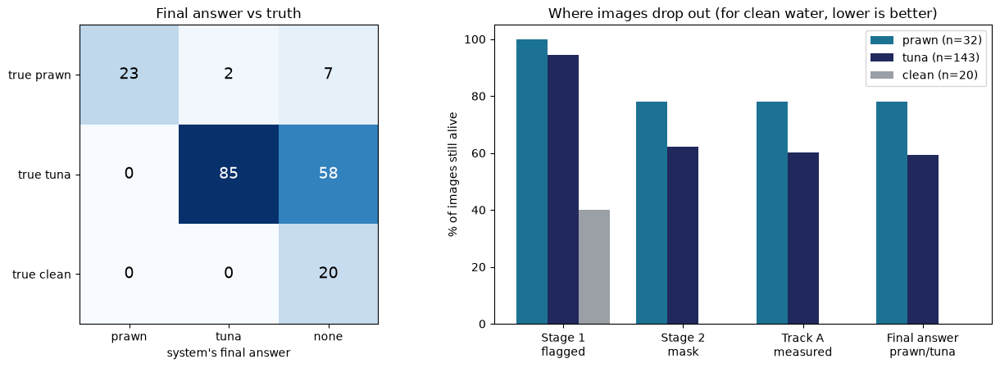

In [10]:
# --- Cell 10: One-picture summary: confusion matrix + stage-by-stage funnel ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(PRED)
ax.set_yticks(range(3)); ax.set_yticklabels([f"true {t}" for t in TRUE])
ax.set_xlabel("system's final answer")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Final answer vs truth")

ax = axes[1]
stages = ["Stage 1\nflagged", "Stage 2\nmask", "Track A\nmeasured", "Final answer\nprawn/tuna"]
width = 0.26
colors = {"prawn": "#1C7293", "tuna": "#21295C", "clean": "#9AA0A6"}
for k, c in enumerate(TRUE):
    n = funnel[c][0]
    vals = [100 * v / n if n else 0 for v in funnel[c][1:]]
    ax.bar(np.arange(4) + (k - 1) * width, vals, width, label=f"{c} (n={n})", color=colors[c])
ax.set_xticks(range(4)); ax.set_xticklabels(stages)
ax.set_ylabel("% of images still alive"); ax.set_ylim(0, 105)
ax.set_title("Where images drop out (for clean water, lower is better)")
ax.legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "stage123_confusion_and_funnel.png", dpi=130, bbox_inches="tight")
print(f"Saved {OUTPUT_DIR / 'stage123_confusion_and_funnel.png'}")
plt.show()

67 wrong final answers out of 195


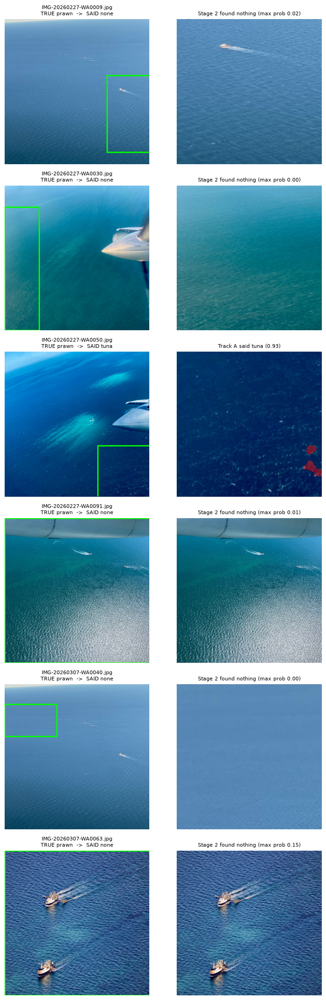

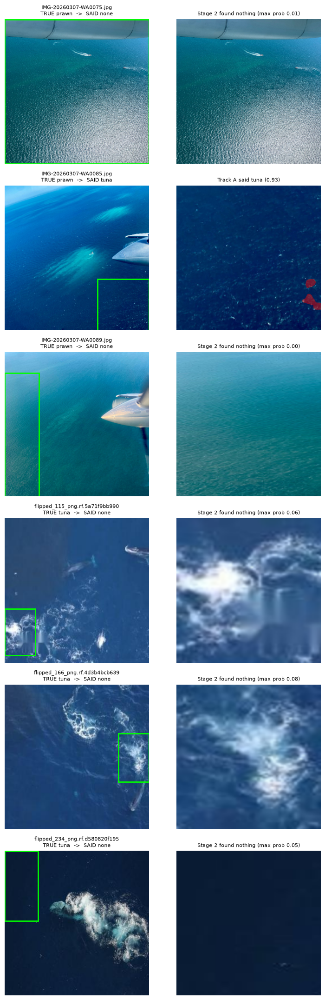

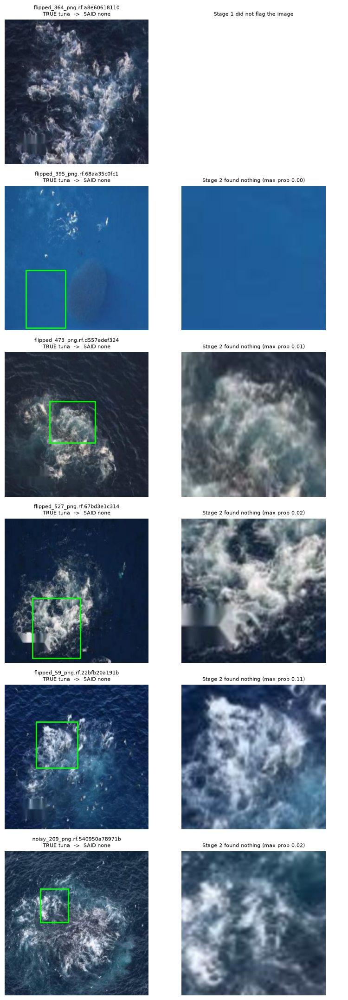

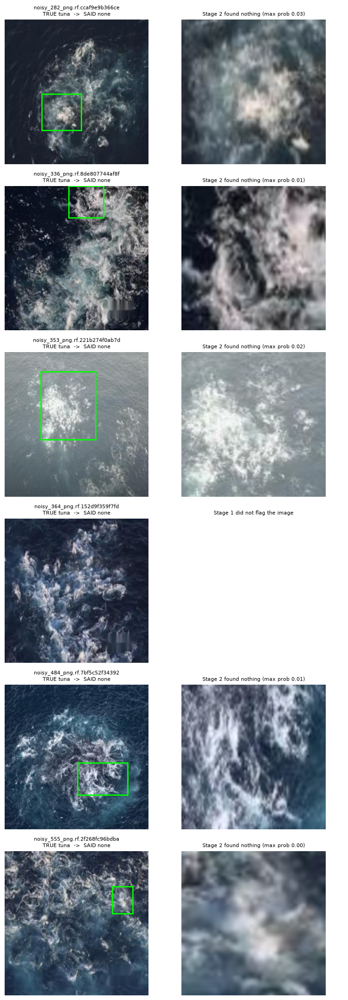

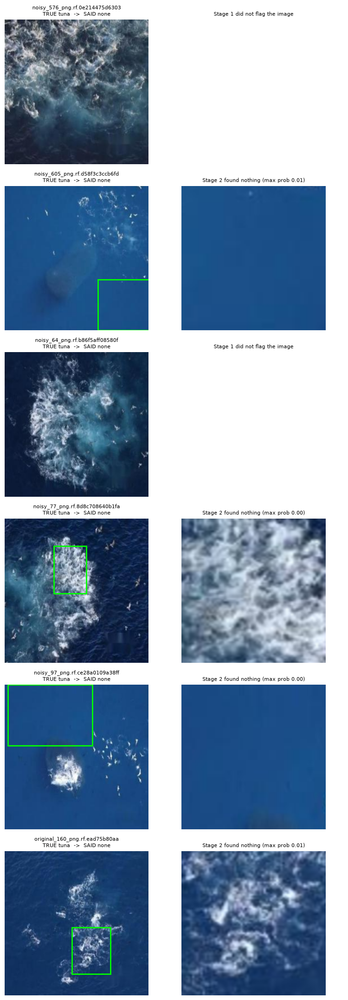

...

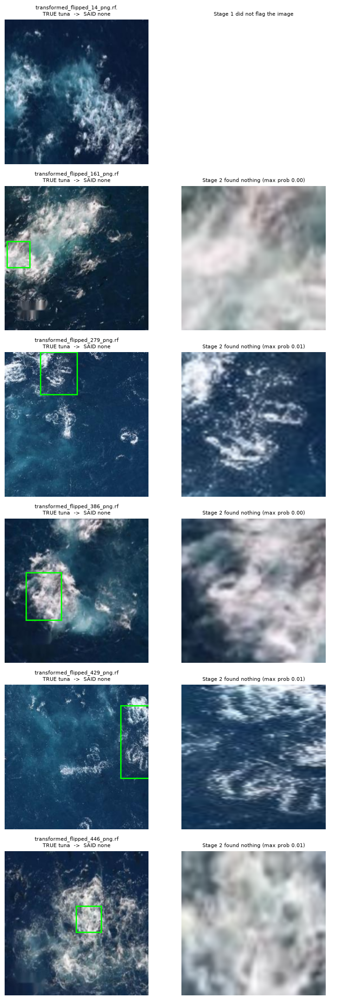

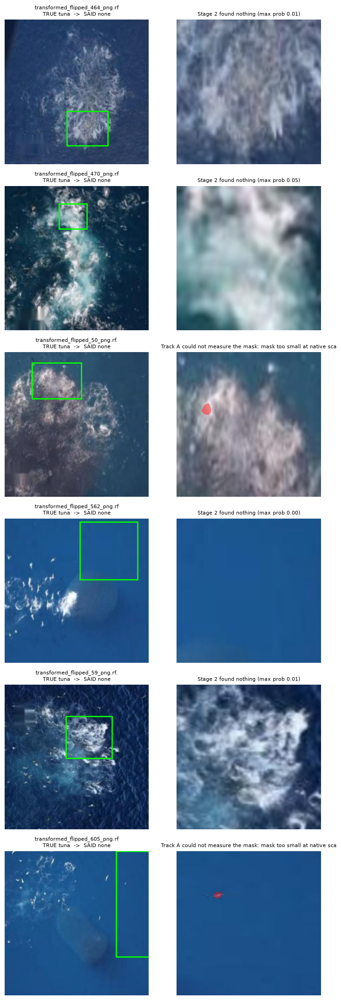

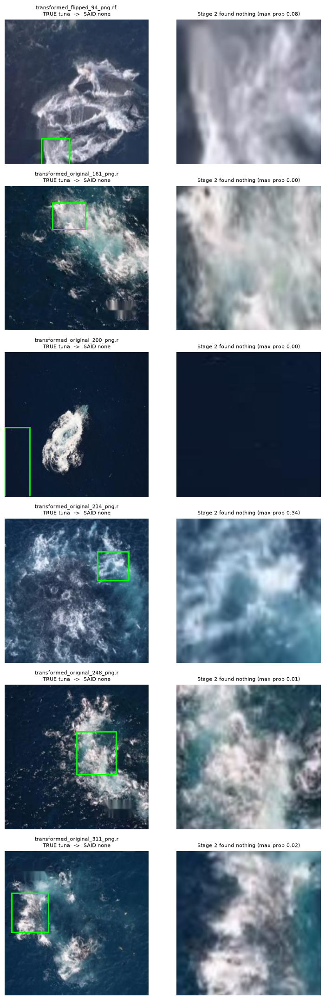

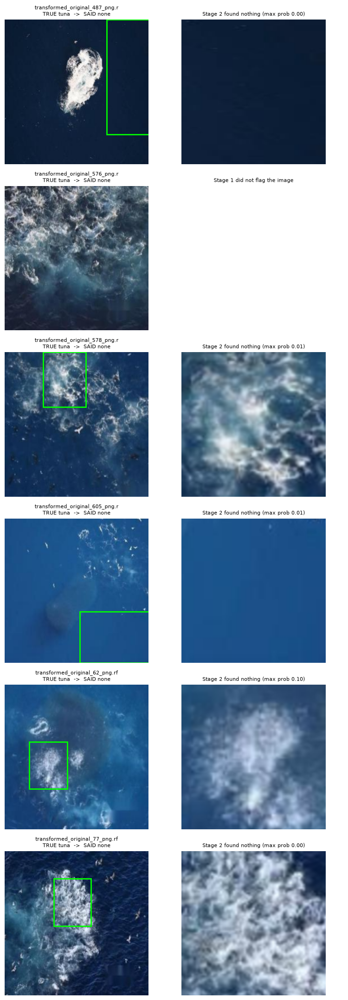

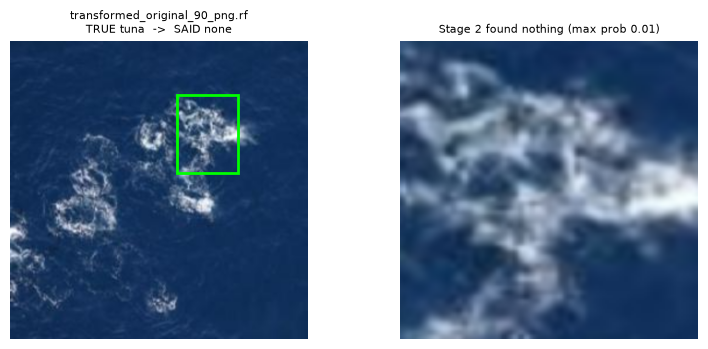

In [11]:
# --- Cell 11: Every wrong answer, with the reason. Green box = Stage 1's region; red = Stage 2's mask. ---

wrong = [r for r in records if not r["correct"]]
print(f"{len(wrong)} wrong final answers out of {len(records)}")

PER_FIGURE = 6          # figures with hundreds of rows can crash the text renderer, so show them in batches
for b in range(0, len(wrong), PER_FIGURE):
    batch = wrong[b:b + PER_FIGURE]
    fig, axes = plt.subplots(len(batch), 2, figsize=(8, 3.6 * len(batch)))
    axes = np.atleast_2d(axes)
    for i, r in enumerate(batch):
        k = kept[r["path"]]
        ax = axes[i, 0]
        ax.imshow(k["rgb"]); ax.axis("off")
        if k["bbox"] is not None:
            x0, y0, x1, y1 = k["bbox"]
            ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2))
        ax.set_title(f"{Path(r['path']).name[:30]}\nTRUE {r['true']}  ->  SAID {r['final']}", fontsize=8)
        ax = axes[i, 1]
        ax.axis("off")
        if k.get("crop") is not None:
            ax.imshow(k["crop"])
            m = k["stage2_mask"]
            if m is not None and m.sum() > 0:
                overlay = np.zeros((*m.shape, 4)); overlay[m == 1] = [1, 0, 0, 0.45]
                ax.imshow(overlay)
        ax.set_title(r["reason"][:64], fontsize=8)
    plt.tight_layout()
    plt.show()

In [12]:
# --- Cell 12 (optional): How accurate are Stage 2's masks on the new images? ---
# Needs COCO annotation JSONs for the new prawn/tuna images (TEST_ANNOTATIONS in cell 1). Skipped otherwise.
# The predicted mask lives inside Stage 1's box, so it is placed back into the 512x512 frame before comparing.

def gt_masks_from_coco(json_path):
    coco = json.load(open(json_path))
    imgs = {i["id"]: i for i in coco["images"]}
    segs = {i: [] for i in imgs}
    for a in coco["annotations"]:
        segs[a["image_id"]].extend(a["segmentation"])
    out = {}
    for i, im in imgs.items():
        m = np.zeros((IMG_SIZE[1], IMG_SIZE[0]), np.uint8)
        sx, sy = IMG_SIZE[0] / im["width"], IMG_SIZE[1] / im["height"]
        for seg in segs[i]:
            pts = np.array([[x * sx, y * sy] for x, y in zip(seg[0::2], seg[1::2])], np.int32)
            cv2.fillPoly(m, [pts], 1)
        out[im["file_name"]] = m
    return out

def frame_space_mask(k):
    frame = np.zeros((IMG_SIZE[1], IMG_SIZE[0]), np.uint8)
    if k["bbox"] is None or k["stage2_mask"] is None or k["stage2_mask"].sum() == 0:
        return frame
    x0, y0, x1, y1 = k["bbox"]
    frame[y0:y1, x0:x1] = cv2.resize(k["stage2_mask"].astype(np.uint8), (x1 - x0, y1 - y0), interpolation=cv2.INTER_NEAREST)
    return frame

def iou(a, b):
    u = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / u) if u else float("nan")

mask_results = {}
if not any(TEST_ANNOTATIONS.values()):
    print("No annotation files given in TEST_ANNOTATIONS - mask accuracy not measured. That is fine.")
else:
    ceilings = {"prawn": PRAWN_IOU_CEILING, "tuna": TUNA_IOU_CEILING}
    for cls, jp in TEST_ANNOTATIONS.items():
        if jp is None:
            continue
        gt = gt_masks_from_coco(jp)
        rows = [r for r in records if r["true"] == cls and Path(r["path"]).name in gt]
        print(f"\n{cls}: {len(rows)} of {sum(1 for r in records if r['true'] == cls)} test images have a matching annotation")
        with_mask, all_ious = [], []
        for r in rows:
            k = kept[r["path"]]
            v = iou(frame_space_mask(k) > 0, gt[Path(r["path"]).name] > 0)
            v = 0.0 if np.isnan(v) else v
            all_ious.append(v)
            if r["stage2_mask_px"] > 0:
                with_mask.append(v)
        if rows:
            print(f"  mean IoU over images that got a mask:        {np.mean(with_mask) if with_mask else float('nan'):.3f}  (n={len(with_mask)})")
            print(f"  mean IoU over all annotated (lost = 0):      {np.mean(all_ious):.3f}  (n={len(all_ious)})")
            print(f"  human-agreement ceiling for {cls}:            {ceilings[cls]:.3f}")
            mask_results[cls] = {"iou_with_mask": float(np.mean(with_mask)) if with_mask else None,
                                 "iou_all": float(np.mean(all_ious)), "n": len(rows)}

No annotation files given in TEST_ANNOTATIONS - mask accuracy not measured. That is fine.


In [13]:
# --- Cell 13: Save the results ---

with open(OUTPUT_DIR / "stage123_per_image_results.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["path", "true", "final", "correct", "ended_at", "reason", "stage1_flagged",
                "stage2_mask_px", "stage2_max_prob"] + [f"prob_{c}" for c in TRACK_A_CLASSES])
    for r in records:
        probs = r["track_a_probs"] or {}
        w.writerow([r["path"], r["true"], r["final"], r["correct"], r["ended_at"], r["reason"], r["stage1_flagged"],
                    r["stage2_mask_px"], r["stage2_max_prob"]] + [probs.get(c, "") for c in TRACK_A_CLASSES])

if audit_rows:
    with open(OUTPUT_DIR / "stage123_lookalike_audit.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(audit_rows[0].keys()))
        w.writeheader()
        w.writerows(audit_rows)

summary["mask_accuracy"] = mask_results
summary["settings"] = mine
summary["track_a_feature_set"] = bundle["feature_set"]
with open(OUTPUT_DIR / "stage123_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved results to {OUTPUT_DIR.resolve()}:")
for p in sorted(OUTPUT_DIR.glob("stage123_*")):
    print(f"  {p.name}")

Saved results to C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\stage123_test_output:
  stage123_confusion_and_funnel.png
  stage123_lookalike_audit.csv
  stage123_per_image_results.csv
  stage123_summary.json
